# Algorithm Apriori

## Importation des bibliothéques 

In [153]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [154]:
data = pd.read_csv('donnees_ecommerce.csv', encoding="ISO-8859-1")

In [155]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Analyse exploratoire

In [156]:
# Dimension
data.shape

(541909, 8)

In [157]:
# Le pourcentage de valeurs manquantes
(data.isnull().sum() / data.shape[0] * 100).sort_values(ascending=False)

CustomerID     24.926694
Description     0.268311
StockCode       0.000000
InvoiceNo       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64

In [158]:
# les lignes dupliquees
data.duplicated().sum() / data.shape[1]

np.float64(658.5)

In [159]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [160]:
data.shape

(541909, 8)

In [161]:
# Quantité négative
(data['Quantity'] < 0).sum()

np.int64(10624)

In [162]:
# Les commandes annulées
(data['InvoiceNo'].astype(str).str.startswith('C')).sum()

np.int64(9288)

In [163]:
starts_with_letter = data[data['StockCode'].str.match(r'^[A-Za-z]')]

print("Nombre de lignes :", len(starts_with_letter))
print(starts_with_letter[['StockCode', 'Description']].head(20))

Nombre de lignes : 2995
         StockCode     Description
45            POST         POSTAGE
141              D        Discount
386           POST         POSTAGE
1123          POST         POSTAGE
1423            C2        CARRIAGE
1814           DOT  DOTCOM POSTAGE
2239             M          Manual
2250             M          Manual
3041           DOT  DOTCOM POSTAGE
4406  BANK CHARGES    Bank Charges
5073          POST         POSTAGE
5258          POST         POSTAGE
5325          POST         POSTAGE
5369          POST         POSTAGE
5450           DOT  DOTCOM POSTAGE
5545           DOT  DOTCOM POSTAGE
5684             M          Manual
5685           DOT  DOTCOM POSTAGE
6165           DOT  DOTCOM POSTAGE
6602          POST         POSTAGE


***Les StockCode commençant par une lettre correspondent à des lignes logistiques, financières ou manuelles (frais de port, remises, charges), qui ne reflètent pas un choix produit du client. Ils ont donc été exclus afin d’éviter des règles d’association artificielles.***

## Preprocessing

In [164]:
df = data.copy()

In [165]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df['Description'] = df['Description'].str.strip()
df.dropna(axis=0, subset=['InvoiceNo', 'Description'], inplace=True)
df = df[df['StockCode'].str[0].str.isdigit()]

In [166]:
# Le pourcentage de valeurs manquantes
(df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)

CustomerID     24.972838
InvoiceNo       0.000000
Description     0.000000
StockCode       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64

In [167]:
# Dimension
df.shape

(528302, 8)

In [168]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [169]:
df['StockCode']

0         85123A
1          71053
2         84406B
3         84029G
4         84029E
           ...  
541904     22613
541905     22899
541906     23254
541907     23255
541908     22138
Name: StockCode, Length: 528302, dtype: object

**Calcul du montant total transactionnel**

In [170]:
# Calcul du montant total
df['Mont_total'] = df['Quantity'] * df['UnitPrice']

In [171]:
df['Country'].value_counts().head(10)

Country
United Kingdom    484533
Germany             8659
France              8100
EIRE                7783
Spain               2423
Netherlands         2326
Switzerland         1936
Belgium             1935
Portugal            1464
Australia           1184
Name: count, dtype: int64

In [172]:
(df['Country'].value_counts() / df.shape[0] * 100).head(5)

Country
United Kingdom    91.715155
Germany            1.639025
France             1.533214
EIRE               1.473210
Spain              0.458639
Name: count, dtype: float64

**Optimisation**

In [ ]:
# On filtre pour ne garder que la France (ou un autre pays) pour réduire la taille
# Ou on garde tout mais on filtre les produits qui apparaissent moins de 10 fois
df_filtered = df[df['Country'] == "France"] 

# Grouper par facture pour obtenir une liste de produits par transaction
transactions = df_filtered.groupby('InvoiceNo')['Description'].apply(list).values.tolist()


***L'utilisation du marché français permet de travailler sur un volume de données réduit et dense, ce qui garantit la stabilité de l'algorithme Apriori sans saturer la mémoire vive de l'ordinateur. Contrairement au Royaume-Uni où les données sont très diluées, la France offre des règles d'association immédiatement significatives avec des scores de lift plus robustes pour l'entraînement du modèle.***

**Encodage**

In [174]:
# Encodage
encoder = TransactionEncoder()
encoded_trans = encoder.fit_transform(transactions)
basket_sets = pd.DataFrame(encoded_trans, columns=encoder.columns_)

In [175]:
print(f"Nombre de transactions uniques : {len(transactions)}")
print(f"Nombre d'items uniques : {len(encoder.columns_)}")
print(f"Shape de la matrice one-hot : {basket_sets.shape}")

Nombre de transactions uniques : 382
Nombre d'items uniques : 1560
Shape de la matrice one-hot : (382, 1560)


In [176]:
print(f"Matrice créée : {basket_sets.shape[0]} transactions et {basket_sets.shape[1]} produits.")

Matrice créée : 382 transactions et 1560 produits.


In [177]:
basket_sets.head()

,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,...,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Mise en oeuvre de l'algorithme Apriori

In [178]:
data['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

**Calcul des itemsets fréquents (Apriori)**

In [179]:
# min_support à 0.05 (5%) pour éviter de saturer la mémoire
frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

**Génération des règles d'association**

In [180]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

**Visualisation**

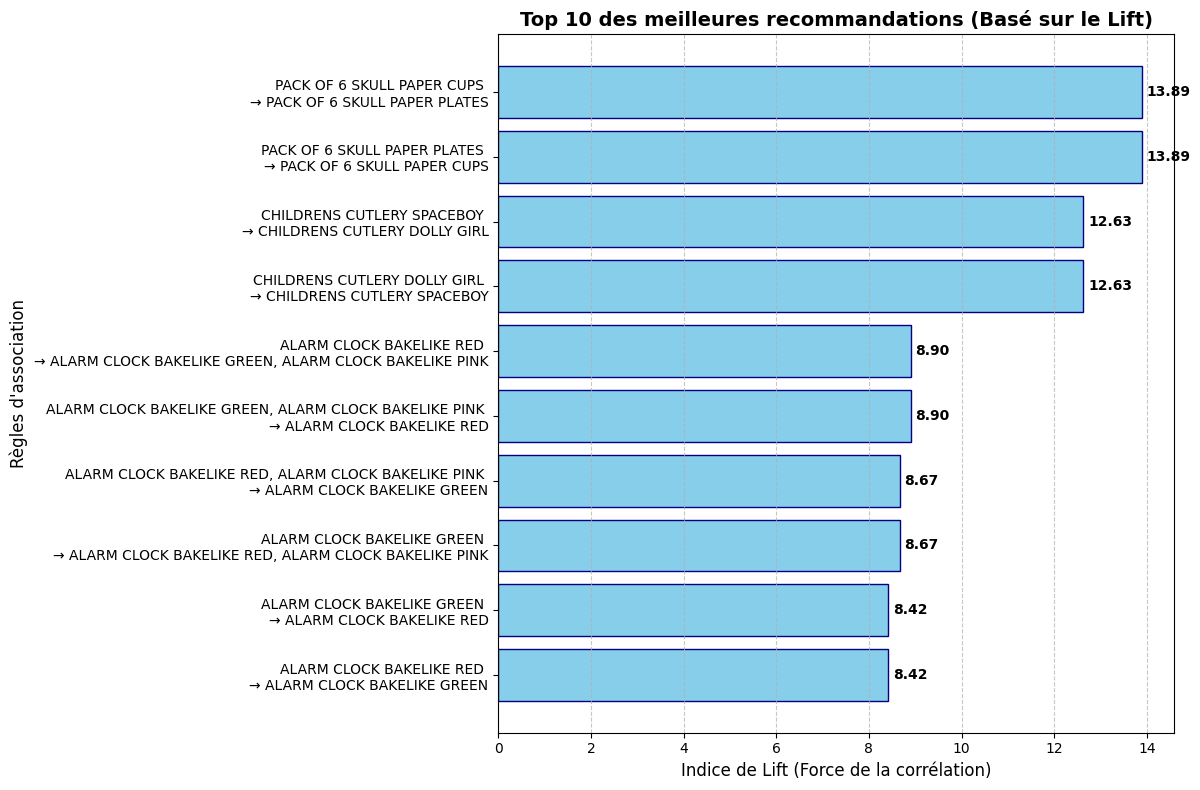

In [181]:

# Préparation du Top 10
# On s'assure que les règles ne sont pas vides
if not rules.empty:
    top_10 = (
        rules.sort_values(by='lift', ascending=False)
             .head(10)
             .copy()
    )

    # 2. Création d'une colonne lisible pour le graphe
    # Comme 'antecedents' et 'consequents' sont des frozensets, on les joint en texte
    top_10['Regle'] = (
        top_10['antecedents'].apply(lambda x: ', '.join(list(x))) +
        ' \n→ ' + 
        top_10['consequents'].apply(lambda x: ', '.join(list(x)))
    )

    # 3. Paramètres du graphe
    plt.figure(figsize=(12, 8))

    # Tracé horizontal avec un dégradé de couleur basé sur le lift
    bars = plt.barh(top_10['Regle'], top_10['lift'], color='skyblue', edgecolor='navy')

    # Ajouter les valeurs de lift au bout des barres pour plus de clarté
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
                 f'{width:.2f}', va='center', fontweight='bold')

    # Inverser l’ordre pour avoir le meilleur lift en haut
    plt.gca().invert_yaxis()

    # Labels et titre
    plt.xlabel("Indice de Lift (Force de la corrélation)", fontsize=12)
    plt.ylabel("Règles d'association", fontsize=12)
    plt.title("Top 10 des meilleures recommandations (Basé sur le Lift)", fontsize=14, fontweight='bold')

    # Nettoyage visuel
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune règle à afficher. Vérifiez votre support minimum.")

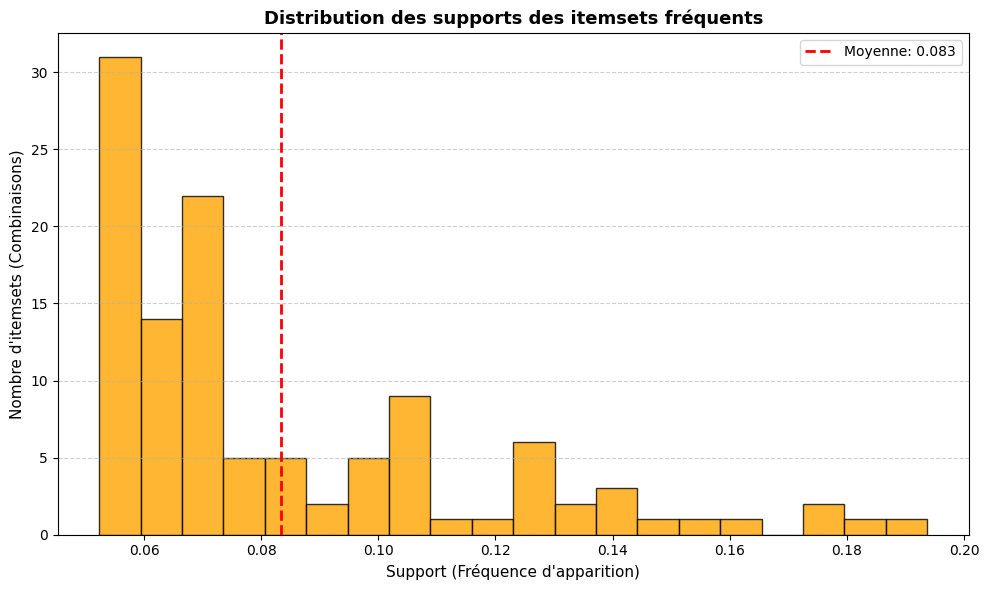

In [182]:

# Vérification si des itemsets ont été trouvés
if not frequent_itemsets.empty:
    plt.figure(figsize=(10, 6))

    # Tracé de l'histogramme
    n, bins, patches = plt.hist(frequent_itemsets['support'], 
                                bins=20, 
                                color='orange', 
                                edgecolor='black', 
                                alpha=0.8)

    # Ajout d'une ligne pour la moyenne du support
    mean_support = frequent_itemsets['support'].mean()
    plt.axvline(mean_support, color='red', linestyle='dashed', linewidth=2, label=f'Moyenne: {mean_support:.3f}')

    # Labels et Titres
    plt.xlabel("Support (Fréquence d'apparition)", fontsize=11)
    plt.ylabel("Nombre d'itemsets (Combinaisons)", fontsize=11)
    plt.title("Distribution des supports des itemsets fréquents", fontsize=13, fontweight='bold')

    # Personnalisation visuelle
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend()
    
    # Ajustement des marges
    plt.tight_layout()
    plt.show()
else:
    print("Aucun itemset fréquent à afficher. Essayez de baisser le 'min_support'.")

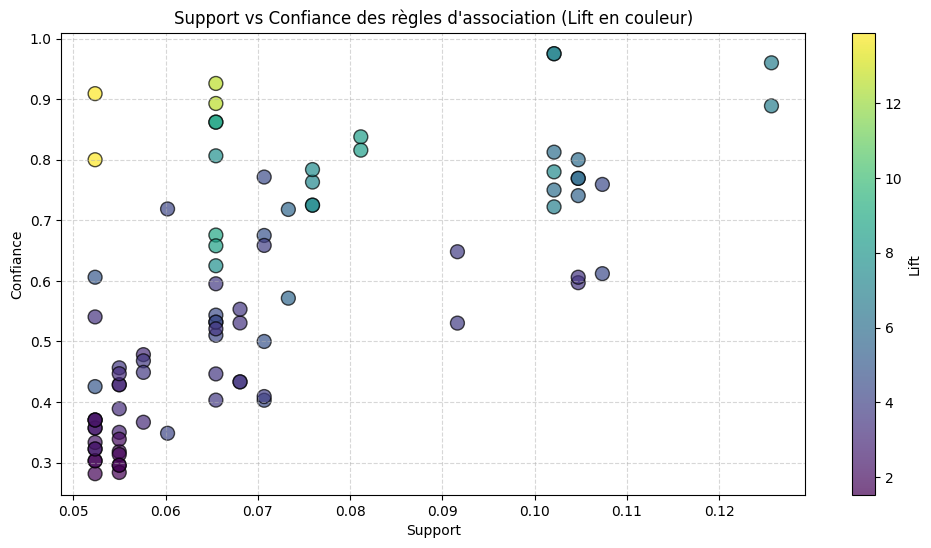

In [183]:
plt.figure(figsize=(12,6))
scatter = plt.scatter(
    rules['support'], 
    rules['confidence'], 
    c=rules['lift'], 
    cmap='viridis', 
    s=100, 
    edgecolor='k', 
    alpha=0.7
)
plt.colorbar(scatter, label='Lift')
plt.xlabel("Support")
plt.ylabel("Confiance")
plt.title("Support vs Confiance des règles d'association (Lift en couleur)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

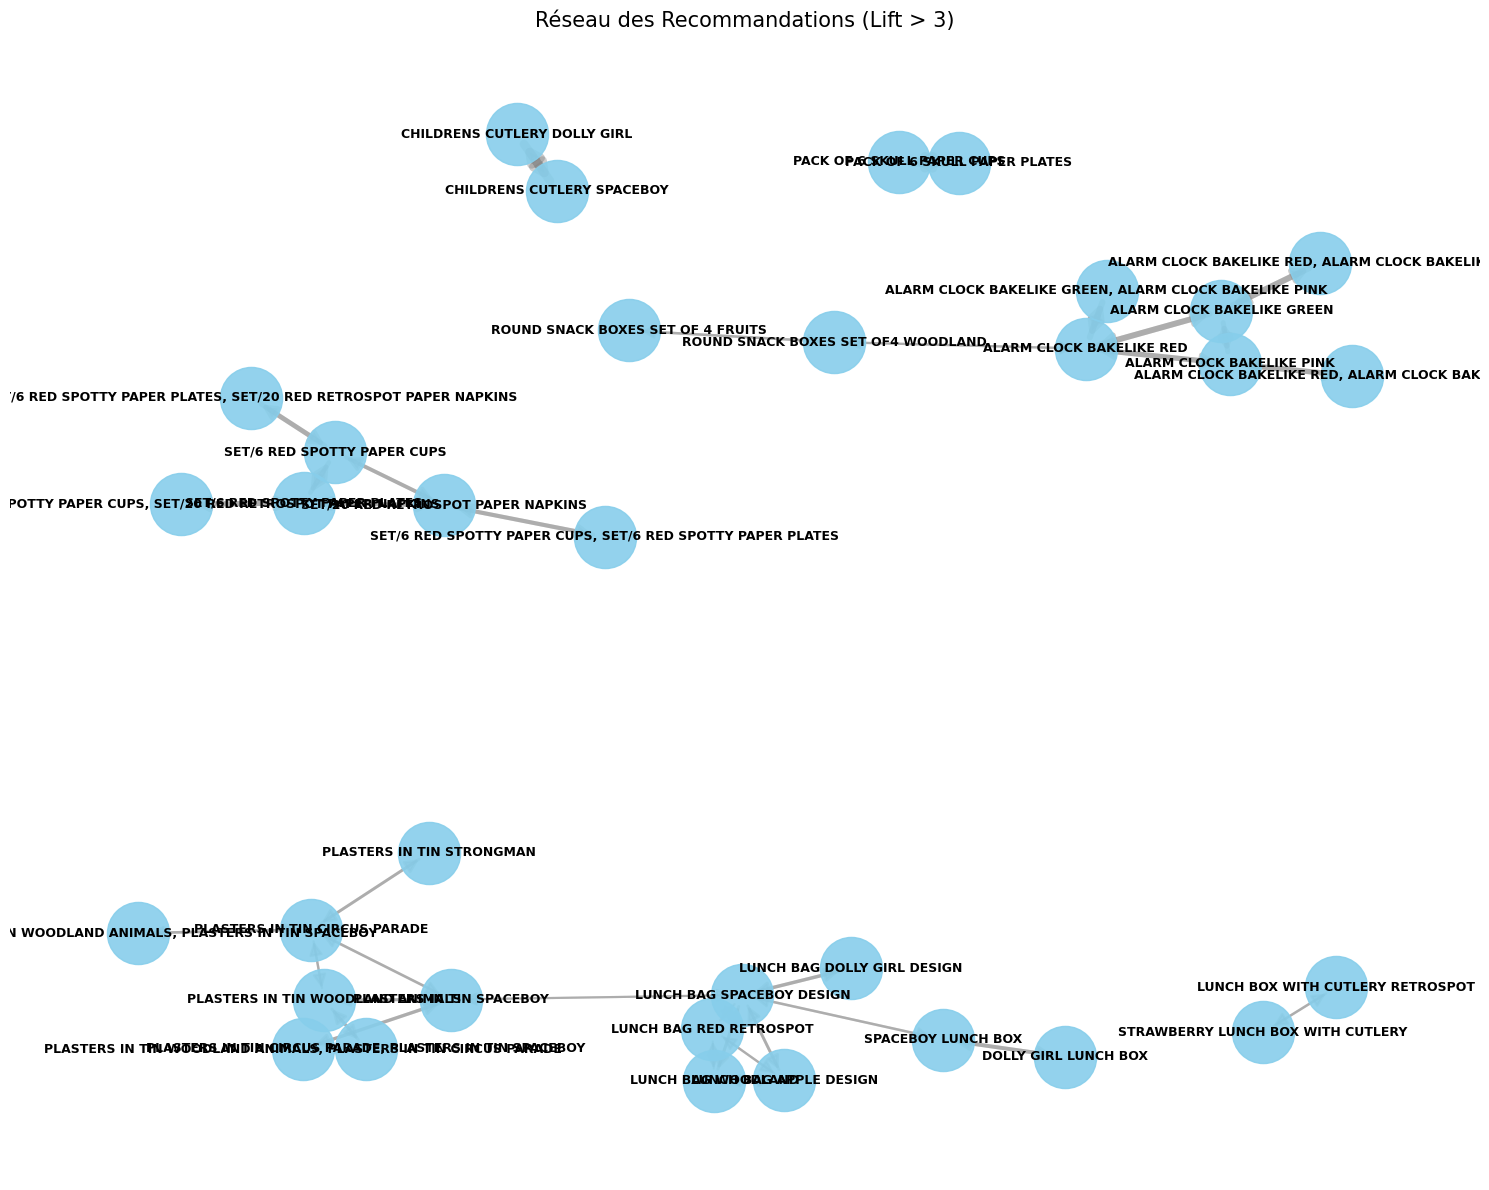

In [184]:
import networkx as nx

# Filtrage des règles pour ne pas surcharger le graphe
# On augmente le seuil de lift (ex: 3) pour ne garder que les liens très forts
threshold_lift = 3
rules_network = rules[rules['lift'] > threshold_lift].copy()

if not rules_network.empty:
    # 2. Créer le graphe orienté
    G = nx.DiGraph()

    # 3. Ajouter les nœuds et les arêtes (liens)
    for _, row in rules_network.iterrows():
        # Transformation des frozensets en chaînes de caractères lisibles
        ant = ', '.join(list(row['antecedents']))
        con = ', '.join(list(row['consequents']))
        lift = row['lift']
        
        G.add_edge(ant, con, weight=lift)

    # 4. Paramètres de mise en page (Layout)
    plt.figure(figsize=(15, 12))
    # spring_layout écarte les nœuds pour plus de lisibilité
    pos = nx.spring_layout(G, k=0.5, seed=42) 

    # 5. Dessin des éléments
    # Les arêtes (flèches) : l'épaisseur dépend du score de Lift
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    # On normalise un peu l'épaisseur pour que ce soit joli
    edge_widths = [w * 0.5 for w in weights] 

    nx.draw_networkx_edges(G, pos, 
                           width=edge_widths, 
                           alpha=0.4, 
                           edge_color='gray', 
                           arrowsize=20)

    # Les nœuds
    nx.draw_networkx_nodes(G, pos, 
                           node_size=2000, 
                           node_color='skyblue', 
                           alpha=0.9)

    # Les étiquettes (noms des produits)
    nx.draw_networkx_labels(G, pos, 
                            font_size=9, 
                            font_family='sans-serif', 
                            font_weight='bold')

    # 6. Titre et affichage
    plt.title(f"Réseau des Recommandations (Lift > {threshold_lift})", fontsize=15)
    plt.axis('off') # Cache les axes X et Y
    plt.tight_layout()
    plt.show()
else:
    print(f"Aucune règle avec un lift supérieur à {threshold_lift} n'a été trouvée.")

***L'analyse s'appuie sur un support de 5% pour isoler les articles récurrents et un seuil de lift supérieur à 3 pour garantir des recommandations hautement prédictives. Cette configuration permet de filtrer le bruit statistique et de ne retenir que les associations de produits ayant une forte probabilité d'achat simultané.***

**FONCTION DE RECOMMANDATION**

In [185]:
def recommander_produit(nom_produit, rules_df, top_n=3):
    nom_produit = nom_produit.upper()
    
    # Trouver les règles où le produit est un antécédent
    # (On vérifie si le nom est présent dans le frozenset)
    preds = rules_df[rules_df['antecedents'].apply(lambda x: nom_produit in [str(i).upper() for i in x])]
    
    # Trier par lift (force du lien)
    preds = preds.sort_values(by='lift', ascending=False)
    
    if preds.empty:
        return None
    
    # Extraire les produits suggérés (consequents)
    recommandations = []
    for cq in preds['consequents']:
        for item in cq:
            if item.upper() != nom_produit and item not in recommandations:
                recommandations.append(item)
    
    return recommandations[:top_n]

**TEST UTILISATEUR**

In [186]:
print("\n" + "="*30)
print("SYSTÈME DE RECOMMANDATION")
print("="*30)

# Afficher quelques exemples de produits dispos pour aider l'utilisateur
exemples = df_filtered['Description'].unique()[:5]
print(f"Exemples de produits : {', '.join(exemples)}")

while True:
    user_input = input("\nEntrez un nom de produit (ou 'stop') : ").strip()
    
    if user_input.lower() == 'stop':
        break
        
    recos = recommander_produit(user_input, rules)
    
    if recos:
        print(f"\nLes clients qui ont acheté [{user_input}] ont aussi pris :")
        for i, r in enumerate(recos, 1):
            print(f" {i}. {r}")
    else:
        print(f"\nAucune recommandation trouvée pour '{user_input}'.")
        print("Vérifiez l'orthographe ou essayez un produit plus commun.")


SYSTÈME DE RECOMMANDATION
Exemples de produits : ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELIKE RED, ALARM CLOCK BAKELIKE GREEN, PANDA AND BUNNIES STICKER SHEET, STARS GIFT TAPE

Les clients qui ont acheté [ALARM CLOCK BAKELIKE PINK] ont aussi pris :
 1. ALARM CLOCK BAKELIKE RED
 2. ALARM CLOCK BAKELIKE GREEN

Les clients qui ont acheté [ALARM CLOCK BAKELIKE RED] ont aussi pris :
 1. ALARM CLOCK BAKELIKE GREEN
 2. ALARM CLOCK BAKELIKE PINK
 3. ROUND SNACK BOXES SET OF4 WOODLAND

Les clients qui ont acheté [ALARM CLOCK BAKELIKE GREEN] ont aussi pris :
 1. ALARM CLOCK BAKELIKE RED
 2. ALARM CLOCK BAKELIKE PINK


**Sauvegarde du modèle**

In [187]:
import pickle
with open ('C:/Users/hp/Desktop/M2/DataMiningInf/final_project/rules.pkl','wb')as f:
    pickle.dump(rules,f)